**CPSC 3810: Final Project**

**Logistic Regression on Citi Bike Demand**

*Group: Denise Pawleen Cabrera, Niki Chen, Theresa Fu*

*Details: Analyzing a Citi Bike dataset to determine in demand times for Citi Bikes around New York City.*

*Methods: Building our own Logistic Regression model and optimizing with both stochastic gradient descent and momentum stochastic gradient descent.*

In [15]:
import numpy as np
import sklearn.datasets as skdata
import sklearn.metrics as skmetrics
from sklearn.linear_model import LogisticRegression as LogisticRegressionSciKit
import matplotlib.pyplot as plt
import warnings 
import time

Implementation of our Logistic Regression model.

In [16]:
# given current weights, this computes gradient and returns updated weights
class Optimizer(object):
    
    def __init__(self, alpha, eta, beta, opt_type):
        
        self.__alpha = alpha
        self.__eta = eta
        self.__beta = beta
        self.__optimizer = opt_type
        self.__momentum = None # hasn't been computed yet
        
    # Computes gradient of the logistic loss. Formula: -(1/N)((yx)/1+exp(yw^Tx))
    def __compute_gradients(self, x, y, w):
        
        # get raw scores
        z = np.matmul(w.T, x)

         # following formula
        yz = y * z
        denominator = 1 + np.exp(yz)
        fraction = y / denominator
        N = x.shape[1]
        gradient = -np.matmul(x, fraction.T) / N
        
        return gradient
    
    # Computes polynomial decay schedule in order to adjust learning rates. Formula is alpha/(time_step^-eta)
    def __polynomial_decay(self, time_step):
        
        p_decay = self.__alpha / (time_step ** self.__eta)
        return p_decay
    
    # Update depending on optimizer
    def update(self, x, y, w, batch_size, time_step):
        
        opt = self.__optimizer
        
        if opt == 'stochastic_gradient_descent':
            
            # randomly choose indices for batch 
            batch_idx = np.random.choice(x.shape[1], size=batch_size, replace=False)
            x_batch = x[:, batch_idx]
            y_batch = y[:, batch_idx]
            
            gradients = self.__compute_gradients(x_batch, y_batch, w)

            # step away from gradient to reduce loss
            w = w - self.__polynomial_decay(time_step) * gradients
            
            return w
            
        elif opt == 'momentum_stochastic_gradient_descent':
            
            # randomly choose indices for batch
            batch_idx = np.random.choice(x.shape[1], size=batch_size, replace=False)
            x_batch = x[:, batch_idx]
            y_batch = y[:, batch_idx]
            
            gradients = self.__compute_gradients(x_batch, y_batch, w)
            
            if self.__momentum is None:
                self.__momentum = np.zeros_like(gradients)
                
            self.__momentum = self.__beta * self.__momentum + (1 - self.__beta) * gradients
            w = w - self.__polynomial_decay(time_step) * self.__momentum
            
            return w
        
        else:
            raise ValueError('Unsupported optimizer type: {}'.format(self.__optimizer))

In [17]:
class LogisticRegression(object):
    
    def __init__(self):
        
        self.__weights = None
        self.__optimizer = None
        
    # creates the optimizer object given chosen hyperparameters and either SGD or momentum SGD
    def fit(self, x, y, T, alpha, eta_decay_factor, beta, batch_size, optimizer_type, loss_func, n_step_per_log=1000, verbose=True):
        self.__optimizer = Optimizer(alpha, eta_decay_factor, beta, optimizer_type)

        # initialize weights to all zeros 
        self.__weights = np.zeros((x.shape[0], 1), dtype=np.float32)

        # empty list to track loss over time for plotting
        loss_values = []

        # loops from step 1 to T
        for t in range(1, T + 1):
            # calls optimizer to take one gradient step, returns updated weights
            self.__weights = self.__optimizer.update(x, y, self.__weights, batch_size, t)

            # if we satisfy how many steps per log, then we will log the result
            if (t % n_step_per_log) == 0:
                loss = self.__compute_loss(x, y, loss_func)
                loss_values.append(loss)

                # verbose just means print the loss at that step
                if verbose:
                    print('Step={}  Loss={}'.format(t, loss))

        # list of losses for plotting the loss curve
        return loss_values
    
    # takes the final learned weights and runs new data through for prediction (which can be assessed for accuracy)
    def predict(self, x):
        z = np.dot(self.__weights.T, x)

        # sigmoid function: squashes any score to a value between 0 and 1 (can be interpreted as a probability)
        p = 1.0 / (1.0 + np.exp(-z))

        # if probability is more >= 0.5, predict class 1. class 0 elsewise. 
        return (p >= 0.5).astype(np.float32)
    
    def __compute_loss(self, x, y, loss_func):
        if loss_func == 'logistic':
            z = np.dot(self.__weights.T, x)
            p = 1.0 / (1.0 + np.exp(-z))

            # binary cross entropy loss formula
            loss = -np.mean(y * np.log(p + 1e-8) + (1.0 - y) * np.log(1.0 - p + 1e-8))
        else:
            raise ValueError('Unsupported loss function: {}'.format(loss_func))

        # sends the loss value back to fit to be logged 
        return loss

Preprocessing the citibike bike availability dataset (30869 samples, 5 feature dimensions)
***** Results on the citibike bike availability dataset using scikit-learn logistic regression model *****
Training set mean accuracy: 0.9468
Validation set mean accuracy: 0.9529
Testing set mean accuracy: 0.9467
***** Results of our logistic regression model trained on citibike bike availability dataset *****
	 optimizer_type=stochastic_gradient_descent 
	 alpha=0.01 
	 eta_decay_factor=0.5 
	 beta=0 
	 batch_size=64 
	 T=7000
Total training time: 3.787053 seconds
Training set mean accuracy: 0.9031
Validation set mean accuracy: 0.8957
Testing set mean accuracy: 0.9062
***** Results of our logistic regression model trained on citibike bike availability dataset *****
	 optimizer_type=momentum_stochastic_gradient_descent 
	 alpha=0.01 
	 eta_decay_factor=0.5 
	 beta=0.9 
	 batch_size=64 
	 T=7000
Total training time: 3.287654 seconds
Training set mean accuracy: 0.9098
Validation set mean accuracy: 

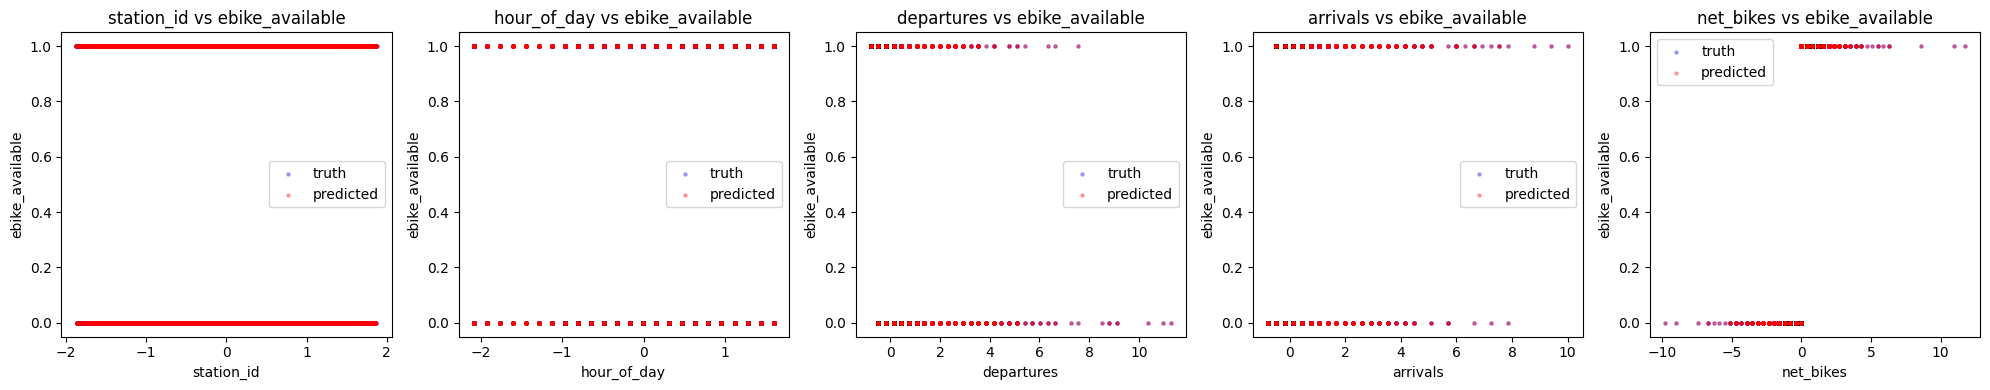

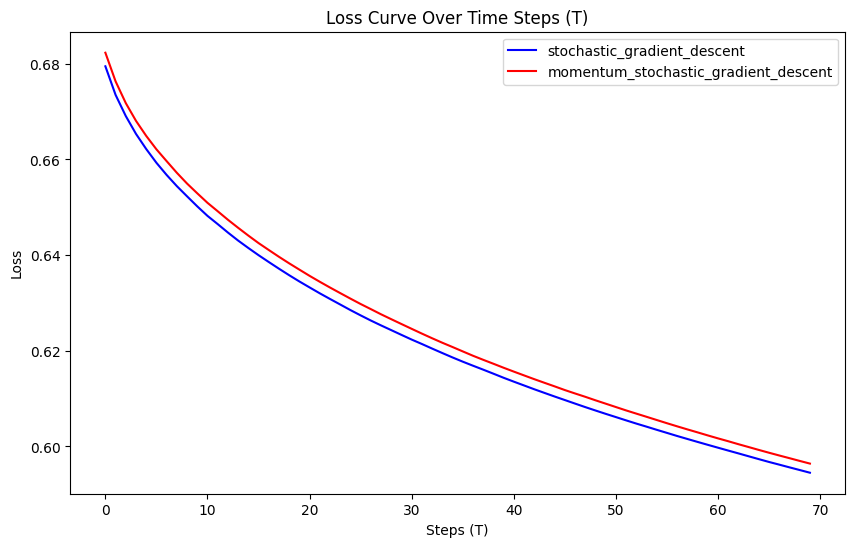

In [20]:
# need this to read csv
import pandas as pd

# need this to basically treat our csv like how our psets have (.data, .target)
from sklearn.utils import Bunch 

# reads csv into a dataframe called df
df = pd.read_csv("https://raw.githubusercontent.com/denise-cbrr/citibike-ml/refs/heads/main/citibike_data.csv")

# converts string station names into integers as our model works with numbers
df['station_id'] = pd.Categorical(df['station_id']).codes

# X is features, y is target (splitting our data)
X = df[['station_id', 'hour_of_day', 'departures', 'arrivals', 'net_bikes']].values
y = df['ebike_available'].values

# Bunch wraps X and y so that later when code does dataset.data and dataset.target it still works (like how assignment was)
datasets = [Bunch(data=X, target=y)]

# Label for print statements
dataset_names = ['citibike bike availability']

# We are going to test with SGD and momentum SGD
dataset_optimizer_types = [
    ['stochastic_gradient_descent', 'momentum_stochastic_gradient_descent']
]

# -------------- Select hyperparameters --------------
# controls how big each step is when updating weights (each has two values, one for SGD and one for momentum SGD)

# base learning rate
dataset_alphas = [
    [0.01, 0.01]
]

# controls how fast the learning rate shrinks over time
dataset_eta_decay_factors = [
    [0.5, 0.5]
]

# controls the role of momentum
dataset_betas = [
    [0, 0.9]
]

# how many rows each step samples
dataset_batch_sizes = [
    [64, 64]
]

# T is the number of training steps
dataset_Ts = [
    [7000, 7000]
]

# Logging options, feel free to edit
dataset_n_step_per_log = [100]
dataset_verbose = [False] # don't print with extra info
 
# Zip up all dataset options (makes it more convenient to loop through)
dataset_options = zip(
    datasets,
    dataset_names,
    dataset_optimizer_types,
    dataset_alphas,
    dataset_eta_decay_factors,
    dataset_betas,
    dataset_batch_sizes,
    dataset_Ts,
    dataset_n_step_per_log,
    dataset_verbose)

for options in dataset_options:

    # Unpack dataset options
    dataset, \
        dataset_name, \
        optimizer_types, \
        alphas, \
        eta_decay_factors, \
        betas, \
        batch_sizes, \
        Ts, \
        n_step_per_log, \
        verbose = options

    '''
    Create the training, validation and testing splits
    '''
    x = dataset.data
    y = dataset.target

    print('Preprocessing the {} dataset ({} samples, {} feature dimensions)'.format(dataset_name, x.shape[0], x.shape[1]))

    # Shuffle the dataset based on sample indices
    shuffled_indices = np.random.permutation(x.shape[0])

    # Choose the first 60% as training set, next 20% as validation and the rest as testing
    train_split_idx = int(0.60 * x.shape[0])
    val_split_idx = int(0.80 * x.shape[0])

    # select the relevant rows according to the above
    train_indices = shuffled_indices[0:train_split_idx]
    val_indices = shuffled_indices[train_split_idx:val_split_idx]
    test_indices = shuffled_indices[val_split_idx:]

    x_train, y_train = x[train_indices, :], y[train_indices]
    x_val, y_val = x[val_indices, :], y[val_indices]
    x_test, y_test = x[test_indices, :], y[test_indices]

    # normalization = scales every feature to have mean 0 and std 1
    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0) + 1e-8

    x_train = (x_train - mean) / std
    x_val = (x_val - mean) / std
    x_test = (x_test - mean) / std

    '''
    Trains and tests logistic regression model from scikit-learn
    '''

    # Creates sklearn's built-in logistic regression, with no regularization
    model_scikit = LogisticRegressionSciKit(penalty=None, fit_intercept=False)

    # Train scikit-learn logistic regression model
    model_scikit.fit(x_train, y_train)

    print('***** Results on the {} dataset using scikit-learn logistic regression model *****'.format(dataset_name))

    # Sore model using mean accuracy on training set
    predictions_train = model_scikit.predict(x_train)
    score_train = skmetrics.accuracy_score(y_train, predictions_train)
    print('Training set mean accuracy: {:.4f}'.format(score_train))

    # Score model using mean accuracy on validation set
    predictions_val = model_scikit.predict(x_val)
    score_val = skmetrics.accuracy_score(y_val, predictions_val)
    print('Validation set mean accuracy: {:.4f}'.format(score_val))

    # Score model using mean accuracy on testing set
    predictions_test = model_scikit.predict(x_test)
    score_test = skmetrics.accuracy_score(y_test, predictions_test)
    print('Testing set mean accuracy: {:.4f}'.format(score_test))

    '''
    Trains, validates, and tests our logistic regression model for binary classification
    '''

    # Take the transpose of the dataset to match the dimensions discussed in lecture
    # i.e., (N x d) to (d x N)
    x_train = np.transpose(x_train, axes=(1, 0))
    x_val = np.transpose(x_val, axes=(1, 0))
    x_test = np.transpose(x_test, axes=(1, 0))
    y_train = np.expand_dims(y_train, axis=0)
    y_val = np.expand_dims(y_val, axis=0)
    y_test = np.expand_dims(y_test, axis=0)

    # Set the ground truth to the appropriate classes (integers) according to lecture
    y_train = y_train.astype(np.float32)
    y_val = y_val.astype(np.float32)
    y_test = y_test.astype(np.float32)

    # Define dictionary to hold optimizer types to loss curve values at logged steps
    loss_curves = {}

    model_options = zip(optimizer_types, alphas, eta_decay_factors, betas, batch_sizes, Ts)

    for optimizer_type, alpha, eta_decay_factor, beta, batch_size, T in model_options:

        # Initialize our logistic regression model
        model_ours = LogisticRegression()

        print('***** Results of our logistic regression model trained on {} dataset *****'.format(dataset_name))
        print('\t optimizer_type={} \n\t alpha={} \n\t eta_decay_factor={} \n\t beta={} \n\t batch_size={} \n\t T={}'.format(
            optimizer_type, alpha, eta_decay_factor, beta, batch_size, T))

        time_start = time.time()

        # Train model on training set
        loss_values = model_ours.fit(
            x=x_train,
            y=y_train,
            T=T,
            alpha=alpha,
            eta_decay_factor=eta_decay_factor,
            beta=beta,
            batch_size=batch_size,
            optimizer_type=optimizer_type,
            loss_func='logistic',
            n_step_per_log=n_step_per_log,
            verbose=verbose
        )

        # SAVE THE INFORMATION
        loss_curves[optimizer_type] = loss_values

        time_elapsed = time.time() - time_start
        print('Total training time: {:3f} seconds'.format(time_elapsed))

        # Score model using mean accuracy on training set
        predictions_train = model_ours.predict(x_train)
        score_train = skmetrics.accuracy_score(
            # flatten because accuracy_score needs a flat array
            y_train.flatten(),
            predictions_train.flatten()
        )
        print('Training set mean accuracy: {:.4f}'.format(score_train))

        # Score model using mean accuracy on validation set
        predictions_val = model_ours.predict(x_val)
        score_val = skmetrics.accuracy_score(
            # flatten because accuracy_score needs a flat array
            y_val.flatten(),
            predictions_val.flatten()
        )
        print('Validation set mean accuracy: {:.4f}'.format(score_val))

        # Score model using mean accuracy on testing set
        predictions_test = model_ours.predict(x_test)
        score_test = skmetrics.accuracy_score(
            # flatten because accuracy_score needs a flat array
            y_test.flatten(),
            predictions_test.flatten()
        )
        print('Testing set mean accuracy: {:.4f}'.format(score_test))

    # outside optimizer loop - scatter plots run once after both optimizers finish
    # Blue dots are the real 0s and 1s from  data, red dots are what our model predicted. Alpha makes dots a bit transparent so u can see them.
    feature_cols = ['station_id', 'hour_of_day', 'departures', 'arrivals', 'net_bikes']

    fig, axes = plt.subplots(1, len(feature_cols), figsize=(20, 4))

    for ax, col, i in zip(axes, feature_cols, range(len(feature_cols))):
        ax.scatter(x_test[i, :], y_test.flatten(), alpha=0.3, s=5, label='truth', color='blue')
        ax.scatter(x_test[i, :], predictions_test.flatten(), alpha=0.3, s=5, label='predicted', color='red')
        ax.set_xlabel(col)
        ax.set_ylabel('ebike_available')
        ax.set_title(f'{col} vs ebike_available')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # loss curve plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    colors = ['blue', 'red']

    for (optimizer_type, loss_values), color in zip(loss_curves.items(), colors):
        ax.plot(loss_values, label=optimizer_type, color=color)

    ax.legend()
    ax.set_title('Loss Curve Over Time Steps (T)')
    ax.set_xlabel('Steps (T)')
    ax.set_ylabel('Loss')
    plt.show()

    print('')